## Lecture 4: Parallel Computing 1 — Peer Review MP1, Amdahl's Law & Multiprocessing

### ****Exercises 1:** MC π Serial**

**Write and time `estimate_pi_serial()`**

****Write** `estimate_pi_serial(num_samples)` — **a plain Python loop:****

**1. Draw two uniform random numbers $x, y ∈ [0, 1)$**

**2. Count a *hit* when $x^2 + y^2 \le 1$**

**3. Return 4 × hits/num samples**

****Time it:** use `time.perf counter()` with 3 runs, take `statistics.median()`. Try `num_samples = 10_000_000`.**

In [1]:
# From slide 38, modified by me to use main function


import math, random, time, statistics
random.seed(0) # Deterministic results (regarding points) I have added this

def estimate_pi_serial(num_samples):
    inside_circle = 0
    for _ in range(num_samples):
        x, y = random.random(), random.random()
        if x*x + y*y <= 1:
            inside_circle += 1
    return 4 * inside_circle / num_samples


def main():
    num_samples = 10_000_000
    times = []
    for _ in range(3):
        t0 = time.perf_counter()
        pi_estimate = estimate_pi_serial(num_samples)
        times.append(time.perf_counter() - t0)
    t_serial = statistics.median(times)
    print(f"pi estimate: {pi_estimate:.6f} (error: {abs(pi_estimate-math.pi):.6f})")
    print(f"Serial time: {t_serial:.3f}s")


if __name__ == '__main__':
    main()

pi estimate: 3.141658 (error: 0.000065)
Serial time: 1.002s


**Questions:**

- **How accurate is the estimate? Run several times — does it vary?**

In [2]:
for i in range(5):
    main()

pi estimate: 3.141837 (error: 0.000244)
Serial time: 0.922s
pi estimate: 3.141890 (error: 0.000297)
Serial time: 0.972s
pi estimate: 3.142002 (error: 0.000409)
Serial time: 0.937s
pi estimate: 3.141593 (error: 0.000000)
Serial time: 0.934s
pi estimate: 3.142273 (error: 0.000680)
Serial time: 0.940s


Worst accuracy was about $\frac{1}{1000}$. We can see that the runtime does vary. This is expected since the points are randomly positioned. 

- **What is the serial time? This will be your speedup denominator in E3.**

It was $T_1 = 1.002$ s.

****Done?** Note your serial time → commit**

```sh
┌──(mikkel@pella)-[~/Sync/AAU/Semester 8/github/nsc-mikkel]
└─$ git log -n 1
commit 403837fbd30986107ca8c81c930cc4d4771e19c1 (HEAD -> main)
Author: mikkel-coder <mikkel.ks.sorensen@gmail.com>
Date:   Thu Mar 5 20:06:40 2026 +0000

    l04: exercise 1 done
```

### ****Exercises 2:** MC π Parallel**

**Parallelize with `Pool.map(); sweep 1. . . cpu count()` workers**

****Parallelize using `Pool.map` — each worker returns a hit count (an integer):****
- **Worker function `estimate_pi_chunk(num samples)`: runs the loop, returns `inside_circle`**
- **Main process: sum worker results, divide by total samples to get $\hat{\pi}$**
- **Why good IPC? Input: one integer per task. Output: one integer per task. No arrays.**

****Sweep** `num_processes` from 1 to `os.cpu count()`. For each worker count: measure elapsed time and compute speedup.**

In [3]:
# From slide 40

from multiprocessing import Pool
import os
import random
import time
import statistics


def estimate_pi_chunk(num_samples):
    inside_circle = 0
    for _ in range(num_samples):
        x, y = random.random(), random.random()
        if x*x + y*y <= 1:
            inside_circle += 1
    return inside_circle


def estimate_pi_parallel(num_samples, num_processes=4):
    samples_per_process = num_samples // num_processes
    tasks = [samples_per_process] * num_processes
    with Pool(processes=num_processes) as pool:
        results = pool.map(estimate_pi_chunk, tasks)
    return 4 * sum(results) / num_samples


if __name__ == '__main__':
    num_samples = 10_000_000
    for num_proc in range(1, os.cpu_count() + 1):
        times = []
        for _ in range(3):
            t0 = time.perf_counter()
            pi_est = estimate_pi_parallel(num_samples, num_proc)
            times.append(time.perf_counter() - t0)
        t = statistics.median(times)
        print(f"{num_proc:2d} workers: {t:.3f}s pi={pi_est:.6f}")

 1 workers: 0.850s pi=3.142342
 2 workers: 0.468s pi=3.141451
 3 workers: 0.346s pi=3.141202
 4 workers: 0.282s pi=3.141625
 5 workers: 0.249s pi=3.141779
 6 workers: 0.252s pi=3.141360
 7 workers: 0.216s pi=3.141729
 8 workers: 0.234s pi=3.142135
 9 workers: 0.252s pi=3.141429
10 workers: 0.221s pi=3.140626
11 workers: 0.226s pi=3.142318
12 workers: 0.226s pi=3.141220
13 workers: 0.230s pi=3.141670
14 workers: 0.242s pi=3.141672
15 workers: 0.228s pi=3.141798
16 workers: 0.231s pi=3.140734


**Questions:**

- **Do all worker counts give the same $\hat{\pi}$? Why or why not?**

No, they do not. This is expected since the points are randomly positioned. This results in some *workers* having more or less points lay inside, which can be seen as the *noise* in the value of pie.

- **At which count do you first see a meaningful speedup?**

From 1 worker to 2 workers, resulting in a speedup of $S = \frac{T_1}{T_2} = \frac{0.850 \text{s}}{0.468 \text{s}} = 1.82\times$.

****Done?** Check $\hat{\pi}$ is consistent across runs → continue to E3**

Noted! It appears that $\hat{\pi}$ is stable.

### ****Exercises 3:** MC π Analysis**

**Speedup curve; efficiency table; back-solve implied serial fraction**

****Parallel efficiency:** $E_p = \frac{S_p}{p}$ — fraction of ideal speedup per core (100% = perfect). **For each worker count (1 to `cpu count()`), tabulate:** workers | time ($s$) | speedup $S_p$ | efficiency $E_p$(%)**

****Questions to discuss:****

**1. At which worker count $p^∗$ is speedup maximum?**

First of all, lets compute the results and save them.

In [4]:
import numpy as np
from pathlib import Path

def compute_results():
    results = [] 
    num_samples = 10_000_000
    for num_proc in range(1, os.cpu_count() + 1):
        times = []
        for _ in range(3):
            t0 = time.perf_counter()
            pi_est = estimate_pi_parallel(num_samples, num_proc)
            times.append(time.perf_counter() - t0)
        t = statistics.median(times)
        print(f"{num_proc:2d} workers: {t:.3f}s pi={pi_est:.6f}")
        results.append(t)
    return results


# Persist the results
results_file = Path("l04_results.npy")
if not results_file.exists():
    res = compute_results()
    np.save(results_file, res)

 1 workers: 0.895s pi=3.142018
 2 workers: 0.472s pi=3.141336
 3 workers: 0.343s pi=3.141011
 4 workers: 0.283s pi=3.140884
 5 workers: 0.247s pi=3.141234
 6 workers: 0.229s pi=3.141175
 7 workers: 0.216s pi=3.141007
 8 workers: 0.206s pi=3.141309
 9 workers: 0.243s pi=3.141387
10 workers: 0.240s pi=3.140991
11 workers: 0.241s pi=3.141343
12 workers: 0.260s pi=3.142051
13 workers: 0.265s pi=3.141754
14 workers: 0.264s pi=3.141576
15 workers: 0.263s pi=3.141297
16 workers: 0.266s pi=3.141016


In [5]:
results = np.load(results_file)

speedups = [results[0] / time_parallel for time_parallel in results]
s_max = max(speedups)
p_star = speedups.index(s_max) + 1

print(f"Maximum speedup of {s_max:.2f}x achieved using {p_star} workers")

Maximum speedup of 4.34x achieved using 8 workers


**2. Does speedup plateau or drop beyond $p^∗$? Why?**

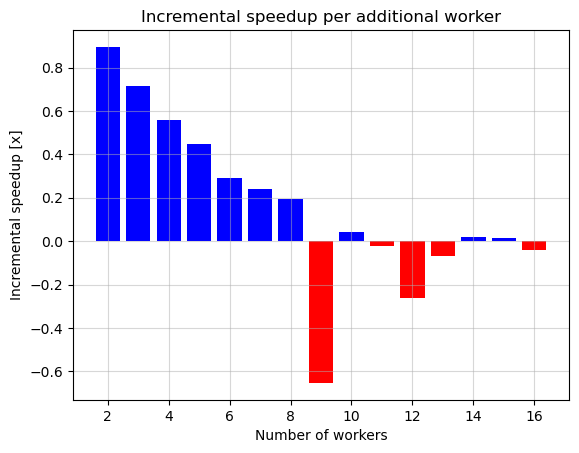

In [6]:
import numpy as np
import matplotlib.pyplot as plt

diff = np.diff(np.array(speedups))
workers = range(2, len(speedups)+1)

# AI assisted colours
colors = []
for d in diff:
    if d > 1: # Superlinear
        colors.append("green")
    elif d > 0: # Normal
        colors.append("blue")
    else: # d < 1 slowdown bad
        colors.append("red")

plt.bar(workers, diff, color=colors)
plt.title("Incremental speedup per additional worker")
plt.ylabel("Incremental speedup [x]")
plt.xlabel("Number of workers")
plt.grid(alpha=0.5)
plt.show()

The plot above shows the difference between the speedup of going form $n$ workers to $n+1$ workers. Expected range is $[0-1]$, $<1$ is a regression or *slowdown*, and $>1$ is a superlinear speedup.

From the plot, we can see that the speedup plateaus for more than 8 workers.

**3. **Back-solve implied serial fraction:** $s = \frac{1/S_{p^*} - 1/p^*}{1 - 1/p^*}$ — what fraction of time is effectively serial (IPC overhead + spawning)?**

In [7]:
s =  (1/s_max - 1/p_star) / (1 - 1/p_star)

print(f"Back-solved: Approximately {s*100:.2f}% is serial.")

Back-solved: Approximately 12.05% is serial.


**4. **Mac M1/M2/M3 users:** do you see a slope change near worker 8 (E-cores)?**

I do own a Mac with any of these processors.

****(Optional) Plot:** workers (x) vs. speedup (y) — actual and ideal linear.**

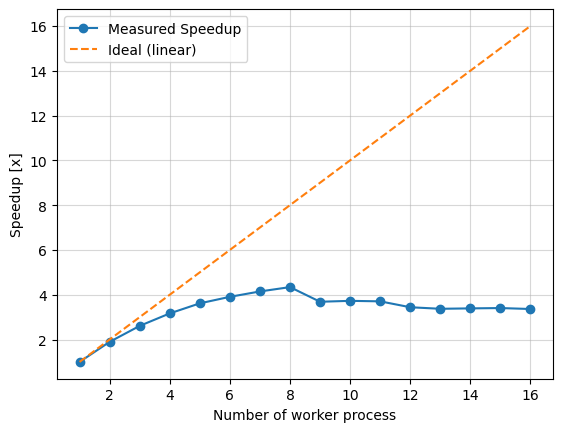

In [8]:
workers = range(1, len(speedups)+1)
ideal = range(1, len(speedups)+1)

plt.plot(workers, speedups, marker="o", label="Measured Speedup")
plt.plot(ideal, ideal, linestyle="--", label="Ideal (linear)")
plt.ylabel("Speedup [x]")
plt.xlabel("Number of worker process")
plt.grid(alpha=0.5)
plt.legend()
plt.show()

****Done?** Discuss with a neighbour → move on to MP2 milestones**

We can see that Simultaneous Multi-Threading SMT (AMD's version of Intel HypeThreading) does not help in terms of speedup. In fact, it seems to result in a slowdown compared to using just the physical number of cores.

*CPU* 8 core, 16 threads